# Data Understanding và Data Preprocessing — HDFS

## 1. Scope và data sources

Mục tiêu: xác định dữ liệu có gì, chất lượng ra sao và cần chuẩn bị thế nào trước experiment.
Notebook **không kết luận phương pháp retrieval/model nào tốt hơn**; đề xuất phương pháp nằm trong
[research design](../docs/research_design.md).

Đơn vị mẫu: một **BlockId**, theo [README gốc của HDFS_v1](../docs/dataset.md). Nhãn tham chiếu từ `anomaly_label.csv`;
chuỗi có thứ tự từ `Event_traces.csv`; text từ `HDFS.log_templates.csv`; đối chiếu số đếm bằng
`Event_occurrence_matrix.csv`. NPZ chỉ đọc header. Chưa đối chiếu raw HDFS.log, chưa xác minh đơn vị
TimeInterval/Latency hoặc ý nghĩa mã Type.

Chọn Python kernel của `.venv`, chạy **Run All** từ thư mục dự án. Các dependency được ghi trong
`requirements-data-understanding.txt`. Phân tích toàn CSV, không lấy mẫu; phần xác minh độc lập
cuối notebook đọc toàn bộ `processed_v2/block_sequences.csv`. Notebook giải thích cả preprocessing,
nhưng final dataset được tạo deterministically bằng `scripts/prepare_data.py` để có thể kiểm thử và tái lập.
Bảng dài được lưu CSV; notebook chỉ hiển thị summary/head(10).


In [1]:
from __future__ import annotations
from collections import Counter, defaultdict
import json
from pathlib import Path
import re
import zipfile
import numpy as np
import pandas as pd
import hashlib
from IPython.display import display, Image
root = Path.cwd()
if not (root / 'preprocessed').exists():  # khi Jupyter dùng notebooks/ làm working directory
    root = root.parent
data_dir = root / 'preprocessed'
output = root / 'outputs' / 'data_understanding'
prepared_dir = root / 'processed_v2'
chunksize = 20000
assert data_dir.is_dir(), 'Mở notebook tại thư mục dự án hoặc sửa root'
pd.set_option('display.max_colwidth', 70)
pd.set_option('display.max_rows', 12)
LABELS = {'Success': 'Normal', 'Fail': 'Anomaly', 'Normal': 'Normal', 'Anomaly': 'Anomaly'}

QUALITY_KEYS = ('matrix_events_without_template', 'templates_without_matrix_column', 'labels_without_matrix', 'matrix_without_labels', 'unknown_ground_truth_labels', 'unknown_matrix_labels', 'unknown_trace_labels', 'matrix_label_disagreement', 'invalid_matrix_cells', 'duplicate_trace_block_ids', 'missing_trace_block_ids', 'trace_label_disagreement', 'malformed_features', 'empty_traces', 'unknown_event_tokens', 'trace_matrix_count_disagreement', 'interval_length_disagreement', 'invalid_intervals', 'invalid_latency', 'latency_vs_interval_sum_disagreement', 'malformed_time_fields', 'labels_without_trace', 'traces_without_labels', 'matrix_without_trace')

TIME_RTOL = 0

TIME_ATOL = 1e-06

def parse_list(value: str) -> list[str]:
    """Features dùng [E5,E22,...], không phải JSON; không sử dụng eval."""
    value = str(value).strip()
    if not (value.startswith('[') and value.endswith(']')):
        raise ValueError(f'Danh sách sai định dạng: {value[:80]}')
    if not value[1:-1].strip():
        return []
    items = [v.strip() for v in value[1:-1].split(',')]
    if any((not item for item in items)):
        raise ValueError('Danh sách có phần tử rỗng hoặc dấu phẩy dư')
    return items

def require_unique(frame: pd.DataFrame, key: str, name: str) -> None:
    if frame[key].isna().any() or frame[key].duplicated().any():
        raise ValueError(f'{name}: {key} thiếu hoặc trùng; cần xử lý trước khi join.')

## 2. File inventory và provenance

Kích thước và SHA256 giúp nhận diện đúng đầu vào khi tái lập. Hash không chứng minh tính đúng của dữ liệu.
Nguồn và các bài cần trích dẫn được ghi trong [README gốc](../docs/dataset.md); notebook không xác minh độc lập quy trình gán nhãn ban đầu.


In [2]:
output.mkdir(parents=True, exist_ok=True)

quality = Counter({key: 0 for key in QUALITY_KEYS})

inventory = []

for path in sorted(data_dir.iterdir()):
    if path.is_file():
        inventory.append({'file': path.name, 'bytes': path.stat().st_size})

pd.DataFrame(inventory).to_csv(output / 'file_inventory.csv', index=False)
def file_sha256(path):
    digest = hashlib.sha256()
    with path.open('rb') as stream:
        for piece in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(piece)
    return digest.hexdigest()
provenance = pd.DataFrame(inventory)
provenance['sha256'] = [file_sha256(data_dir / name) for name in provenance.file]
provenance.to_csv(output / 'source_provenance.csv', index=False)
display(provenance)


,file,bytes,sha256
0,Event_occurrence_matrix.csv,53099247,59ab8b8a6d12f18f41b35e9eb0113655825b9bf9d9787c1a6f72fface7cc01a7
1,Event_traces.csv,125412805,68cd80eac007b28f5ca10d8acceb104d61067e74e1c4eef2c6c6015b2d769d3c
2,HDFS.log_templates.csv,1607,92e5200c9ddd9c38730d1a983c957e2a36b34cf8bd9434a6eba46932b1c3b1d4
3,HDFS.npz,52907681,0ccfacd40ff339f7f1755906f8121c1589a20acb8a2a625839a5caa9f66d91a7
4,anomaly_label.csv,18637554,1c711ed6c8848fc3243fb4d092f172f31d128c8a6ec7f26ebba72ab931885ed8


## 3. Schema validation

Kiểm tra cột bắt buộc, khóa không thiếu/trùng trước khi join. Thiếu schema hoặc khóa không duy nhất
làm cell dừng, không tạo báo cáo thành công giả. `Features` không phải JSON; parser không dùng eval,
không bỏ qua âm thầm phần tử rỗng. Các mảng JSON trong artifact đã chuẩn bị được xử lý riêng ở mục 12.


In [3]:
templates = pd.read_csv(data_dir / 'HDFS.log_templates.csv')

labels = pd.read_csv(data_dir / 'anomaly_label.csv')

matrix = pd.read_csv(data_dir / 'Event_occurrence_matrix.csv')

for frame, key, name in [(templates, 'EventId', 'templates'), (labels, 'BlockId', 'labels'), (matrix, 'BlockId', 'matrix')]:
    require_unique(frame, key, name)
trace_schema = pd.read_csv(data_dir / 'Event_traces.csv', nrows=5)
required = [(templates, {'EventId','EventTemplate'}), (labels, {'BlockId','Label'}),
            (matrix, {'BlockId','Label','Type'}),
            (trace_schema, {'BlockId','Label','Type','Features','TimeInterval','Latency'})]
for table, columns in required:
    assert columns.issubset(table.columns), f'Missing columns: {columns - set(table.columns)}'
display(pd.DataFrame([{'file': name, 'columns': ', '.join(table.columns)} for name,table in
    [('templates',templates),('labels',labels),('matrix',matrix),('traces',trace_schema)]]))
display(templates.head(5))


,file,columns
0,templates,"EventId, EventTemplate"
1,labels,"BlockId, Label"
2,matrix,"BlockId, Label, Type, E1, E2, E3, E4, E5, E6, E7, E8, E9, E10, E11..."
3,traces,"BlockId, Label, Type, Features, TimeInterval, Latency"


,EventId,EventTemplate
0,E1,[*]Adding an already existing block[*]
1,E2,[*]Verification succeeded for[*]
2,E3,[*]Served block[*]to[*]
3,E4,[*]Got exception while serving[*]to[*]
4,E5,[*]Receiving block[*]src:[*]dest:[*]


## 4. Cross-file integrity checks

Đối chiếu toàn bộ BlockId, nhãn (`Success→Normal`, `Fail→Anomaly`), template mapping và số đếm từng
sự kiện. N sự kiện phải có N−1 khoảng thời gian. Tổng TimeInterval so với Latency dùng
**rtol=0, atol=1e-6**; tính nhất quán này không xác định đơn vị thời gian.

Cell này tính các thống kê dùng cho mục 5–10 trong một lượt đọc trace. Các key chất lượng được
khởi tạo bằng 0 trước khi kiểm tra; danh mục và tolerance được lưu trong `quality_check_schema.json`.
Thống kê transition đếm cả occurrences và số BlockId chứa cặp sự kiện (mỗi cặp tối đa một lần/block).


In [4]:
events = [c for c in matrix if re.fullmatch('E\\d+', c)]

template_map = templates.set_index('EventId')['EventTemplate'].to_dict()

quality['matrix_events_without_template'] = len(set(events) - set(template_map))

quality['templates_without_matrix_column'] = len(set(template_map) - set(events))

truth = labels.set_index('BlockId')['Label']

matrix = matrix.set_index('BlockId')

quality['labels_without_matrix'] = len(set(truth.index) - set(matrix.index))

quality['matrix_without_labels'] = len(set(matrix.index) - set(truth.index))

quality['unknown_ground_truth_labels'] = int((~truth.isin(['Normal', 'Anomaly'])).sum())

quality['unknown_matrix_labels'] = int((~matrix.Label.isin(LABELS)).sum())

aligned = truth.reindex(matrix.index)

quality['matrix_label_disagreement'] = int((matrix.Label.map(LABELS) != aligned).sum())

counts = matrix[events].apply(pd.to_numeric, errors='coerce')

invalid = counts.isna() | (counts < 0) | (counts % 1 != 0)

quality['invalid_matrix_cells'] = int(invalid.sum().sum())

if quality['invalid_matrix_cells']:
    raise ValueError('Ma trận chứa số đếm thiếu, âm hoặc không nguyên.')

missing = matrix.isna().sum().rename('missing').to_frame()

missing['fraction'] = missing['missing'] / len(matrix)

missing.to_csv(output / 'matrix_missing_values.csv')

stats = templates.set_index('EventId').reindex(events)

for label in ['Normal', 'Anomaly']:
    subset = counts.loc[aligned == label]
    stats[f'{label}_occurrences'] = subset.sum()
    stats[f'{label}_blocks'] = (subset > 0).sum()
    stats[f'{label}_prevalence'] = (subset > 0).mean()

stats['prevalence_difference'] = stats.Anomaly_prevalence - stats.Normal_prevalence

stats.to_csv(output / 'event_statistics.csv')

patterns = defaultdict(Counter)

transitions = {label: Counter() for label in ['Normal', 'Anomaly', 'Unknown']}

transition_blocks = {label: Counter() for label in transitions}

seen = set()

features = []

examples = defaultdict(list)

trace_missing = Counter()

for chunk in pd.read_csv(data_dir / 'Event_traces.csv', chunksize=chunksize):
    trace_missing.update(chunk.isna().sum().to_dict())
    expected_rows = counts.reindex(chunk.BlockId).to_numpy()
    for row, expected in zip(chunk.itertuples(index=False), expected_rows):
        block = row.BlockId
        quality['missing_trace_block_ids'] += int(pd.isna(block))
        quality['unknown_trace_labels'] += int(row.Label not in LABELS)
        quality['duplicate_trace_block_ids'] += int(block in seen)
        seen.add(block)
        label = truth.get(block, 'Unknown')
        if label not in transitions:
            label = 'Unknown'
        quality['trace_label_disagreement'] += int(LABELS.get(row.Label) != label)
        try:
            sequence = parse_list(row.Features)
        except ValueError:
            quality['malformed_features'] += 1
            continue
        event_counts = Counter(sequence)
        quality['empty_traces'] += int(not sequence)
        quality['unknown_event_tokens'] += sum((v for k, v in event_counts.items() if k not in template_map))
        quality['trace_matrix_count_disagreement'] += int(not np.array_equal([event_counts[e] for e in events], expected) or bool(set(sequence) - set(events)))
        try:
            intervals = np.asarray([float(v) for v in parse_list(row.TimeInterval)])
            latency = float(row.Latency)
            quality['interval_length_disagreement'] += int(len(intervals) != max(len(sequence) - 1, 0))
            quality['invalid_intervals'] += int((~np.isfinite(intervals) | (intervals < 0)).sum())
            quality['invalid_latency'] += int(not np.isfinite(latency) or latency < 0)
            quality['latency_vs_interval_sum_disagreement'] += int(not np.isclose(intervals.sum(), latency, rtol=TIME_RTOL, atol=TIME_ATOL))
        except (ValueError, TypeError):
            quality['malformed_time_fields'] += 1
            latency = float('nan')
        patterns[tuple(sequence)][label] += 1
        transitions[label].update(zip(sequence, sequence[1:]))
        transition_blocks[label].update(set(zip(sequence, sequence[1:])))
        features.append((block, label, row.Type, len(sequence), len(event_counts), latency))
        if len(examples[label]) < 2:
            examples[label].append({'BlockId': block, 'label_for_analysis_only': label, 'events': sequence, 'template_sequence': [template_map.get(e, e) for e in sequence]})

quality['labels_without_trace'] = len(set(truth.index) - seen)

quality['traces_without_labels'] = len(seen - set(truth.index))

quality['matrix_without_trace'] = len(set(matrix.index) - seen)

frame = pd.DataFrame(features, columns=['BlockId', 'Label', 'Type', 'length', 'unique_events', 'latency'])

frame.to_csv(output / 'trace_features.csv', index=False)

summary = frame.groupby('Label')[['length', 'unique_events', 'latency']].describe(percentiles=[0.5, 0.9, 0.95, 0.99])

summary.to_csv(output / 'trace_summary_by_label.csv')

pd.Series(trace_missing, name='missing').to_csv(output / 'trace_missing_values.csv')

frame.groupby(['Label', 'Type'], dropna=False).size().rename('blocks').to_csv(output / 'type_distribution.csv')

type_rows = []

for source, values, source_labels in [('matrix', matrix.Type, aligned), ('traces', frame.Type, frame.Label)]:
    for label in ('Normal', 'Anomaly'):
        selected = values.loc[source_labels == label]
        type_rows.append({'source': source, 'label': label, 'blocks': len(selected), 'Type_missing': int(selected.isna().sum()), 'Type_present': int(selected.notna().sum())})

pd.DataFrame(type_rows).to_csv(output / 'type_missingness_by_label.csv', index=False)

pattern_rows = [{'sequence': ' '.join(seq), 'blocks': sum(c.values()), 'Normal': c['Normal'], 'Anomaly': c['Anomaly'], 'Unknown': c['Unknown']} for seq, c in patterns.items()]

pattern_df = pd.DataFrame(pattern_rows).sort_values('blocks', ascending=False)

pattern_df.to_csv(output / 'sequence_patterns.csv', index=False)

conflicts = pattern_df[(pattern_df.Normal > 0) & (pattern_df.Anomaly > 0)]

conflicts.to_csv(output / 'conflicting_sequences.csv', index=False)

transition_rows = [{'label': label, 'from': a, 'to': b, 'count': count, 'fraction_within_class': count / sum(counter.values())} for label, counter in transitions.items() for (a, b), count in counter.most_common()]

pd.DataFrame(transition_rows).to_csv(output / 'transitions.csv', index=False)

all_pairs = sorted(set().union(*(set(counter) for counter in transitions.values())))

transition_prevalence = []

class_sizes = frame.Label.value_counts()

for a, b in all_pairs:
    record = {'from': a, 'to': b}
    for label in ('Normal', 'Anomaly'):
        containing = transition_blocks[label][a, b]
        record[f'{label}_blocks_containing_transition'] = containing
        record[f'{label}_transition_prevalence'] = containing / class_sizes[label] if class_sizes.get(label, 0) else float('nan')
    transition_prevalence.append(record)

pd.DataFrame(transition_prevalence).to_csv(output / 'transition_block_prevalence.csv', index=False)

(output / 'trace_examples.json').write_text(json.dumps(examples, ensure_ascii=False, indent=2), encoding='utf-8')

npz_metadata = []

npz_path = data_dir / 'HDFS.npz'

if npz_path.exists():
    with zipfile.ZipFile(npz_path) as archive:
        for name in archive.namelist():
            if not name.endswith('.npy'):
                continue
            with archive.open(name) as stream:
                version = np.lib.format.read_magic(stream)
                if version == (1, 0):
                    shape, order, dtype = np.lib.format.read_array_header_1_0(stream)
                elif version == (2, 0):
                    shape, order, dtype = np.lib.format.read_array_header_2_0(stream)
                else:
                    npz_metadata.append({'name': name, 'unsupported_header_version': version})
                    continue
                npz_metadata.append({'name': name, 'shape': shape, 'dtype': str(dtype), 'fortran_order': order})

(output / 'npz_metadata.json').write_text(json.dumps(npz_metadata, indent=2), encoding='utf-8')

(output / 'quality_checks.json').write_text(json.dumps(quality, indent=2), encoding='utf-8')

(output / 'quality_check_schema.json').write_text(json.dumps({'schema_version': 2, 'checked_keys': QUALITY_KEYS, 'zero_means': 'checked, no violation found', 'time_rtol': TIME_RTOL, 'time_atol': TIME_ATOL, 'time_units': 'unverified', 'key_and_schema_checks': 'fail-fast; no successful report if required columns or unique keys are invalid'}, indent=2), encoding='utf-8')
assert set(quality) == set(QUALITY_KEYS)
nonzero_quality = {key: value for key,value in quality.items() if value}
print(f'Đã kiểm tra {len(frame):,} traces; {len(QUALITY_KEYS)} quality counters.')
print('Các counter khác 0:', nonzero_quality)
print('Chi tiết:', output / 'quality_checks.json')
from scripts.eda_visuals import make_eda_plots
figure_paths = make_eda_plots(output)
plot_status = f'Đã tạo {len(figure_paths)} biểu đồ EDA trong figures/.'


Đã kiểm tra 575,061 traces; 24 quality counters.
Các counter khác 0: {}
Chi tiết: /mnt/e/learn/Do an/code/outputs/data_understanding/quality_checks.json


## 5. Label distribution và Type leakage

Anomaly-class F1 là metric chính; thêm Precision, Recall, confusion matrix và class counts của test.
Accuracy chỉ là bổ sung. Always-Normal có Recall/F1 Anomaly bằng 0; Precision khi không dự đoán positive
không xác định, chỉ báo cáo 0 nếu ghi rõ quy ước `zero_division=0`.

**Type không được dùng làm input, kể cả indicator `Type.notna()`.** Cell dưới kiểm tra trực tiếp
trạng thái có/thiếu của Type so với nhãn trong cả hai CSV. Nếu hai trạng thái đồng nhất với nhãn,
đó là feature mã hóa trực tiếp target trong dữ liệu này. Không cần biết ý nghĩa mã mới loại feature này.
Ý nghĩa mã vẫn chưa được xác minh; chỉ dùng hậu nghiệm sau khi có tài liệu giải nghĩa.

Precision/F1 trên subset cân bằng lại không đại diện trực tiếp cho prevalence dataset này.
Không suy rộng tỷ lệ Anomaly của HDFS_v1 thành prevalence chung của mọi hệ thống HDFS.


,blocks,fraction
Label,,
Normal,558223,0.97072
Anomaly,16838,0.02928


,source,label,blocks,Type_missing,Type_present
0,matrix,Normal,558223,558223,0
1,matrix,Anomaly,16838,0,16838
2,traces,Normal,558223,558223,0
3,traces,Anomaly,16838,0,16838


Type.notna() khớp nhãn Anomaly trên toàn bộ mẫu của cả matrix và traces.
Always-Normal Accuracy: 97.0720%; Anomaly Recall=0, F1=0


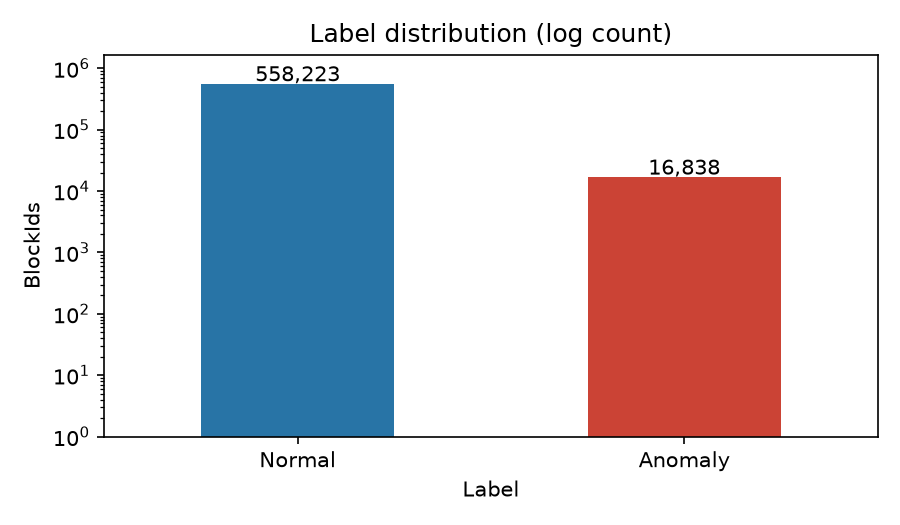

In [5]:
label_distribution = truth.value_counts().rename('blocks').to_frame()
label_distribution['fraction'] = label_distribution.blocks / len(truth)
display(label_distribution)
type_table = pd.read_csv(output / 'type_missingness_by_label.csv')
display(type_table)
type_mismatches = int(type_table.loc[type_table.label.eq('Normal'), 'Type_present'].sum()
                      + type_table.loc[type_table.label.eq('Anomaly'), 'Type_missing'].sum())
assert type_mismatches == 0, 'Type missingness không còn đồng nhất với nhãn; cần sửa kết luận'
print('Type.notna() khớp nhãn Anomaly trên toàn bộ mẫu của cả matrix và traces.')
print(f"Always-Normal Accuracy: {(truth == 'Normal').mean():.4%}; Anomaly Recall=0, F1=0")
display(Image(filename=str(output / 'figures/label_distribution.png')))


## 6. Event statistics và transition prevalence

Event prevalence = số BlockId chứa sự kiện / số BlockId trong lớp. Chênh lệch prevalence là liên hệ
thống kê, chưa chứng minh baseline tuyến tính/KNN sẽ đạt điểm cao; đây là lý do để đánh giá baseline
đơn giản trước khi kết luận giá trị tăng thêm của LLM/RAG.

`fraction_within_class` trong transitions.csv chia cho tổng số occurrences của lớp, nên trace dài có
trọng số lớn hơn. `transition_block_prevalence.csv` chia số block chứa cặp cho số block của lớp.
Occurrence vectors mất thứ tự; transitions chỉ giữ cấu trúc cục bộ. EDA không kết luận representation nào tốt hơn.


,EventTemplate,Normal_occurrences,Normal_blocks,Normal_prevalence,Anomaly_occurrences,Anomaly_blocks,Anomaly_prevalence,prevalence_difference
EventId,,,,,,,,
E9,[*]Received block[*]of size[*]from[*],1674669,558223,1.000000,31845,10631,0.631370,-0.368630
E26,[*]BLOCK* NameSystem[*]addStoredBlock: blockMap updated:[*]is adde...,1679485,558223,1.000000,40256,10631,0.631370,-0.368630
E11,[*]PacketResponder[*]for block[*]terminating[*],1674669,558223,1.000000,32010,10657,0.632914,-0.367086
E20,[*]Unexpected error trying to delete block[*]BlockInfo not found i...,222,219,0.000392,5323,5126,0.304430,0.304038
E18,[*]Starting thread to transfer block[*]to[*],2543,1779,0.003187,4459,3492,0.207388,0.204201
E25,[*]BLOCK* ask[*]to replicate[*]to[*],2543,1779,0.003187,4459,3492,0.207388,0.204201
E6,[*]Received block[*]src:[*]dest:[*]of size[*],2617,1778,0.003185,4480,3465,0.205785,0.202599
E16,[*]:Transmitted block[*]to[*],2542,1778,0.003185,4395,3465,0.205785,0.202599
E23,[*]BLOCK* NameSystem[*]delete:[*]is added to invalidSet of[*],1364251,454678,0.814510,31923,10337,0.613909,-0.200601


,from,to,Normal_blocks_containing_transition,Normal_transition_prevalence,Anomaly_blocks_containing_transition,Anomaly_transition_prevalence,prevalence_difference
261,E9,E11,554539,0.993400,10132,0.601734,-0.391666
161,E26,E26,556368,0.996677,10420,0.618838,-0.377839
27,E11,E9,558217,0.999989,10631,0.631370,-0.368620
272,E9,E26,483579,0.866283,8710,0.517282,-0.349000
102,E21,E20,219,0.000392,4985,0.296057,0.295664
159,E26,E23,267133,0.478542,3849,0.228590,-0.249952
157,E26,E21,1857,0.003327,4131,0.245338,0.242011
231,E5,E5,557401,0.998527,13225,0.785426,-0.213102
126,E23,E21,453896,0.813109,10179,0.604525,-0.208583
97,E20,E21,128,0.000229,3412,0.202637,0.202408


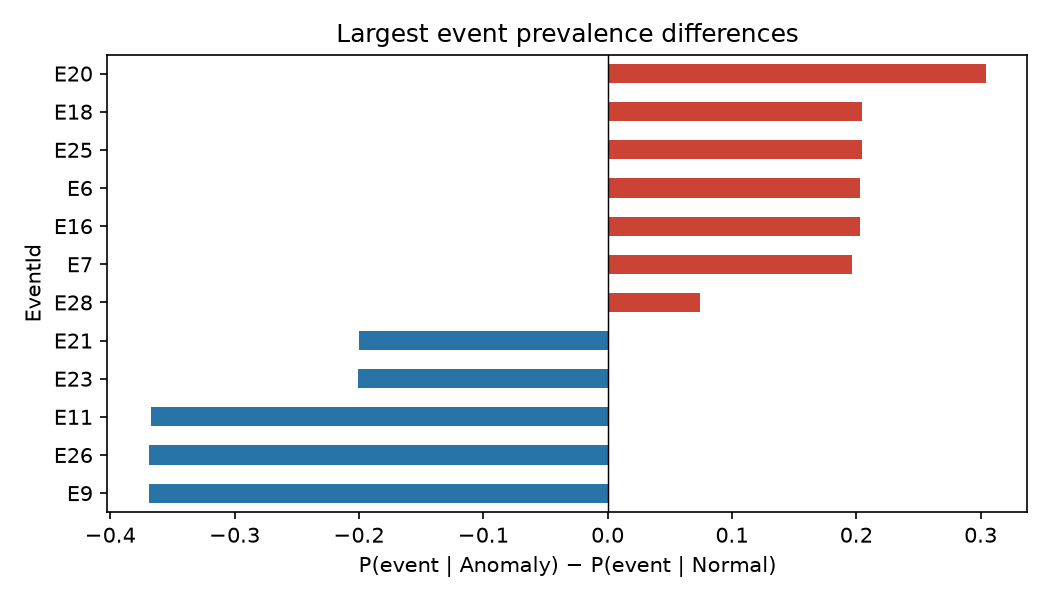

In [6]:
display(stats.loc[stats.prevalence_difference.abs().nlargest(10).index])
transition_table = pd.DataFrame(transition_prevalence)
transition_table['prevalence_difference'] = transition_table.Anomaly_transition_prevalence - transition_table.Normal_transition_prevalence
display(transition_table.loc[transition_table.prevalence_difference.abs().nlargest(10).index])
display(Image(filename=str(output / 'figures/event_prevalence_difference.png')))


## 7. Trace-length và timing statistics

ECDF cho biết tỷ lệ BlockId có giá trị không vượt quá x, tính riêng từng lớp. Biểu đồ unique events
cũng chuẩn hóa theo lớp. Latency chỉ mô tả giá trị lưu trong CSV; **đơn vị chưa xác minh**,
không dùng làm feature chính. Trục latency dùng symlog để thể hiện cả 0 và phần đuôi dài.


length                                                             \
            count       mean        std   min   50%   90%   95%   99%    max   
Label                                                                          
Anomaly   16838.0  17.119017  12.409644   2.0  20.0  30.0  38.0  42.0  284.0   
Normal   558223.0  19.503637   4.775583  13.0  19.0  25.0  28.0  32.0  298.0   

        unique_events  ...         latency                                   \
                count  ...   max     count          mean           std  min   
Label                  ...                                                    
Anomaly       16838.0  ...  20.0   16838.0  14089.464960  18376.636894  0.0   
Normal       558223.0  ...  14.0  558223.0  16870.912341  17865.694194  0.0   

                                                       
            50%      90%       95%       99%      max  
Label                                                  
Anomaly  4920.5  48810.9  51205.15  53133.26  53924.0  
Normal   7303.0  48138.0  50800.90  53188.00  54025.0  

[2 rows x 27 columns]

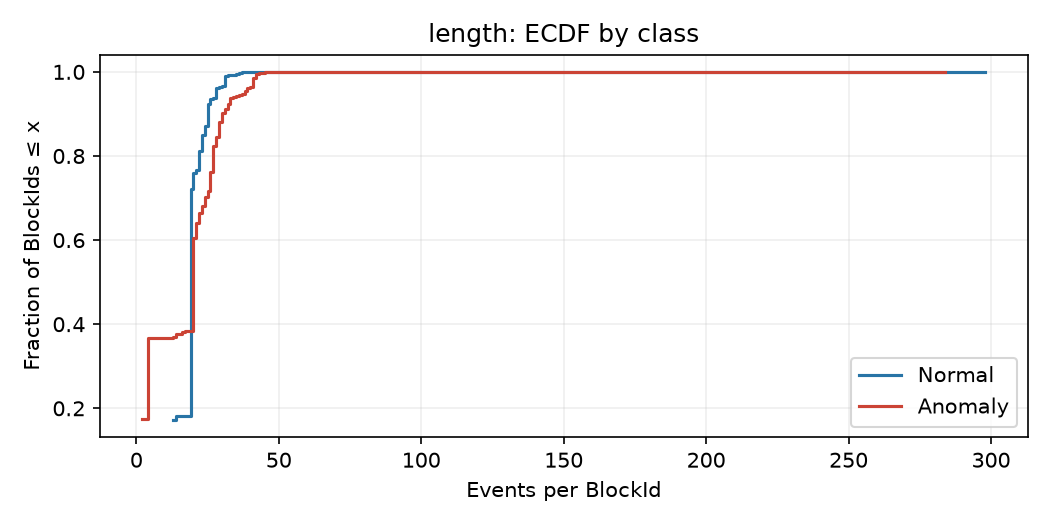

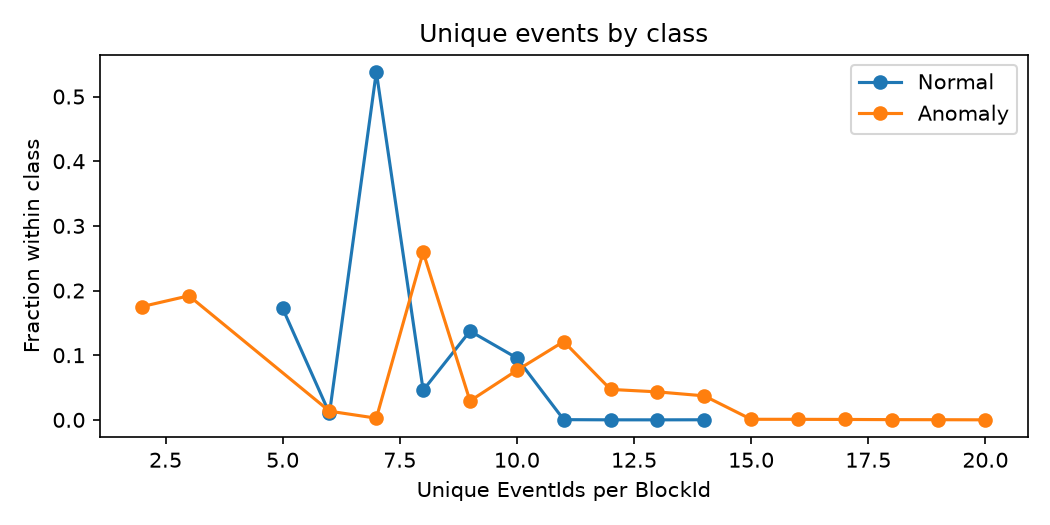

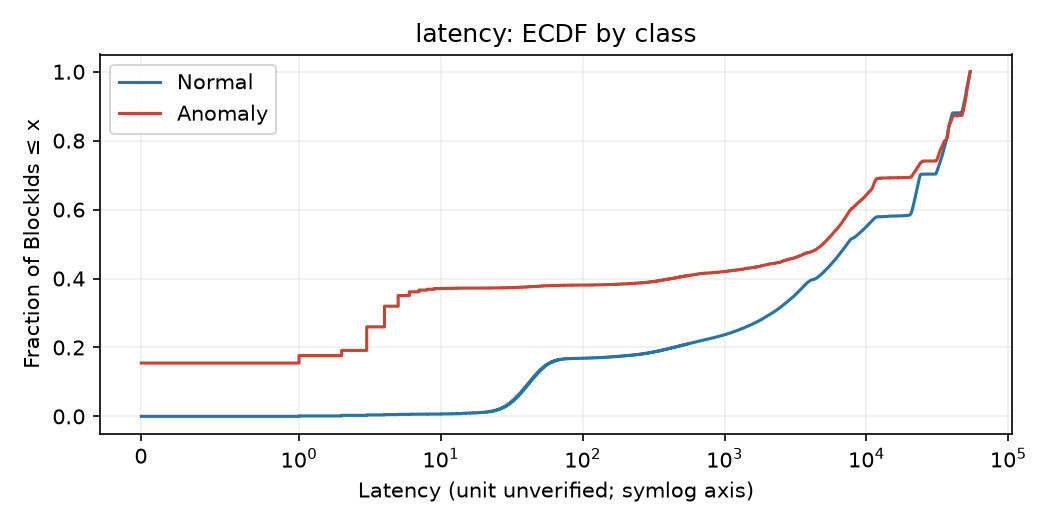

In [7]:
display(summary)
for name in ['trace_length', 'unique_events', 'latency']:
    display(Image(filename=str(output / 'figures' / f'{name}.png')))


## 8. Duplicate-pattern analysis

Phân biệt **trace thuộc nhóm lặp** với **bản sao dư có thể loại bỏ**: nhóm có 3 BlockId đóng góp
3 trace vào chỉ số thứ nhất, nhưng chỉ có 2 bản sao dư. Canonicalization trong KB tiết kiệm số record,
không đồng nghĩa đã đo mức giảm byte index, thời gian embedding hoặc cải thiện chất lượng retrieval.
Giữ occurrence_count từ **Normal train**; bước này dùng chung cho các pipeline, không phải đóng góp adaptive.


,BlockIds,unique_sequences,traces_in_repeated_groups,fraction_in_repeated_groups,redundant_copies
0,575061,18373,564097,0.980934,556688


,blocks,Normal,Anomaly
3936,94794,94794,0
4128,50728,50728,0
3999,47926,47926,0
15630,31213,31213,0
4487,21475,21475,0
15634,19312,19312,0
15633,18297,18297,0
4177,16538,16538,0
4054,9011,9011,0
15648,5962,5962,0


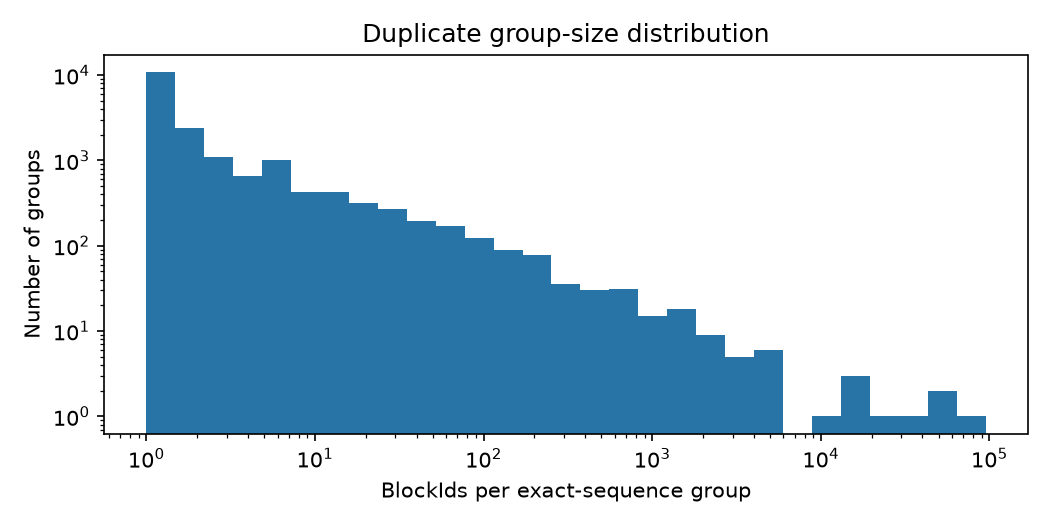

In [8]:
duplicate_summary = pd.DataFrame([{
    'BlockIds': len(frame), 'unique_sequences': len(pattern_df),
    'traces_in_repeated_groups': int(pattern_df.loc[pattern_df.blocks > 1,'blocks'].sum()),
    'fraction_in_repeated_groups': pattern_df.loc[pattern_df.blocks > 1,'blocks'].sum() / len(frame),
    'redundant_copies': len(frame) - len(pattern_df),
}])
display(duplicate_summary)
display(pattern_df[['blocks','Normal','Anomaly']].head(10))
display(Image(filename=str(output / 'figures/duplicate_group_sizes.png')))


## 9. Conflicting-label analysis

Một số exact EventId sequences có cả hai nhãn. Đây là ambiguity của biểu diễn đối với nhãn quan sát,
không tự xác định nguyên nhân. Timing, tham số bị loại hoặc quy trình gán nhãn là giả thuyết chưa kiểm chứng.
Giữ các mẫu trong dataset; cờ conflict từ nhãn toàn dataset chỉ phục vụ phân tích hậu nghiệm.
Không dùng cờ này để lọc test, route query hoặc làm feature.

Tổng min(Normal,Anomaly) theo nhóm là số lỗi tối thiểu trên toàn nhãn hiện có của bộ phân loại
tất định chỉ dùng exact sequence, không phải giới hạn lỗi của từng test split hoặc giới hạn F1.


In [9]:
conflict_summary = pd.DataFrame([{
    'conflicting_unique_sequences': len(conflicts),
    'affected_blocks': int(conflicts.blocks.sum()),
    'affected_fraction': conflicts.blocks.sum() / len(frame),
    'empirical_minimum_sequence_only_errors': int(conflicts[['Normal','Anomaly']].min(axis=1).sum()),
}])
display(conflict_summary)
conflict_sequences = set(conflicts.sequence)
conflict_parts = []
for chunk in pd.read_csv(data_dir / 'Event_traces.csv', chunksize=chunksize):
    signatures = chunk.Features.map(lambda value: ' '.join(parse_list(value)))
    mask = signatures.isin(conflict_sequences)
    if mask.any():
        selected = chunk.loc[mask].copy()
        selected['sequence'] = signatures.loc[mask]
        selected['ground_truth_label'] = selected.BlockId.map(truth)
        conflict_parts.append(selected)
ambiguous = pd.concat(conflict_parts, ignore_index=True) if conflict_parts else pd.DataFrame()
assert len(ambiguous) == int(conflicts.blocks.sum())
ambiguous.to_csv(output / 'ambiguous_block_details.csv', index=False)
if len(ambiguous):
    display(ambiguous[['BlockId','ground_truth_label','Type','Latency']].head(10))
print('Toàn bộ chi tiết:', output / 'ambiguous_block_details.csv')


,conflicting_unique_sequences,affected_blocks,affected_fraction,empirical_minimum_sequence_only_errors
0,10,46,0.00008,11


,BlockId,ground_truth_label,Type,Latency
0,blk_-8531310335568756456,Anomaly,4.0,51107
1,blk_6005203045226256208,Normal,NaN,51564
2,blk_8749974174824944353,Normal,NaN,34444
3,blk_8557172101111875221,Anomaly,21.0,34458
4,blk_6260640408845718216,Normal,NaN,34277
5,blk_8833245999009450801,Normal,NaN,34616
6,blk_8219212597580975288,Normal,NaN,34175
7,blk_8158213312481011298,Normal,NaN,34360
8,blk_8854461689052716268,Normal,NaN,33974
9,blk_8652185270033723455,Normal,NaN,33999


Toàn bộ chi tiết: /mnt/e/learn/Do an/code/outputs/data_understanding/ambiguous_block_details.csv


## 10. Data-quality conclusions

Các quality counters phản ánh đúng những kiểm tra đã chạy, không phải chứng nhận dữ liệu tuyệt đối sạch.
Type missingness đã được kiểm tra riêng và là feature gây label leakage. Ba mục còn chưa xác minh:
NPZ content so với CSV, đơn vị timing, ý nghĩa mã Type. Raw log chưa được audit.
Các mục này không chặn experiment chỉ dùng EventId/template từ CSV.

Báo cáo Markdown được lưu thành artifact; không render lại toàn bộ nội dung ở đây.


In [10]:
distribution = truth.value_counts()

n = len(truth)

duplicated = int(pattern_df.loc[pattern_df.blocks > 1, 'blocks'].sum())

report = f'# Data Understanding — HDFS và Enhanced RAG\n\n## 1. Phạm vi và đơn vị phân tích\nPhân tích toàn bộ CSV tại `{data_dir.resolve()}`; không lấy mẫu.\nTheo docs/dataset.md của dataset, các log được nhóm theo BlockId và gán nhãn ở cấp block.\nMột trace là chuỗi sự kiện của một block; nhãn Anomaly không có nghĩa mọi dòng trong trace đều bất thường.\nScript chỉ kiểm tra metadata của HDFS.npz; chưa xác minh nội dung NPZ khớp CSV.\n\n## 2. Các file và ý nghĩa\n- HDFS.log_templates.csv: EventId → mẫu thông điệp; [*] đại diện phần biến đổi đã bị loại khỏi template.\n- anomaly_label.csv: nhãn Normal/Anomaly theo BlockId, dùng làm nhãn tham chiếu khi đối chiếu.\n- Event_traces.csv: Features giữ thứ tự sự kiện; TimeInterval và Latency là đặc trưng thời gian.\n- Kiểm tra TimeInterval có N-1 phần tử cho trace N sự kiện và tổng khoảng thời gian khớp Latency.\n- Event_occurrence_matrix.csv: số lần xuất hiện từng EventId, mất thông tin thứ tự.\n- Success được ánh xạ sang Normal, Fail sang Anomaly và kiểm tra lại bằng BlockId.\n- Type bị loại cùng mọi indicator missingness: trạng thái có/thiếu của nó mã hóa nhãn trong dataset này.\n  Ý nghĩa mã chưa xác minh; chỉ phân tích hậu nghiệm sau khi có tài liệu giải nghĩa.\n- Chưa xác minh đơn vị thời gian từ mã tiền xử lý; không mặc định giây hoặc mili giây.\n\n## 3. Thống kê đo được\n- Số block có nhãn: {n:,}.\n- Normal: {distribution.get('Normal', 0):,}; Anomaly: {distribution.get('Anomaly', 0):,} ({distribution.get('Anomaly', 0) / n:.2%}).\n- Số template: {len(templates)}; số cột sự kiện: {len(events)}.\n- Số trace phân tích được: {len(frame):,}; số chuỗi sự kiện phân biệt: {len(pattern_df):,}.\n- Số trace thuộc nhóm chuỗi xuất hiện nhiều lần: {duplicated:,}.\n- Số chuỗi giống hệt nhau nhưng có cả hai nhãn: {len(conflicts):,}, bao phủ {int(conflicts.blocks.sum()):,} trace.\n\nThống kê độ dài, số loại sự kiện và latency (gồm p50/p90/p95/p99): trace_summary_by_label.csv.\nevent_statistics.csv ghi cả tần suất tuyệt đối và tỷ lệ block chứa sự kiện trong từng lớp;\nchênh lệch prevalence chỉ là liên hệ thống kê trên dataset, không chứng minh nguyên nhân.\ntransitions.csv đếm cặp sự kiện liền kề trong từng trace, không nối giữa các block.\ntransition_block_prevalence.csv đếm mỗi cặp tối đa một lần mỗi BlockId và chia cho số block từng lớp;\nkhác với fraction_within_class có trọng số theo số lần transition xuất hiện.\n\n## 4. Kiểm tra chất lượng\nGiá trị dưới đây là số vi phạm/khác biệt, trừ các trường tên rõ là số template hoặc token.\nSchema kiểm tra cố định nằm trong quality_check_schema.json; mọi key đều xuất hiện, kể cả 0.\nSo sánh tổng TimeInterval với Latency dùng rtol=0, atol=1e-6; đây là kiểm tra giả thuyết về cách tiền xử lý,\nkhác biệt chưa đủ để kết luận dữ liệu sai. Type thiếu có thể là có chủ đích.\n\n```json\n{json.dumps(quality, indent=2)}\n```\n\n## Phạm vi experiment và các mục chưa xác minh\n\nBa mục sau vẫn **chưa được xác minh**; các kiểm tra chất lượng đã chạy không bao phủ chúng:\n\n| Mục | Trạng thái hiện tại | Khi nào cần xác minh thêm? |\n| --- | --- | --- |\n| Nội dung `HDFS.npz` có khớp CSV | Mới đọc metadata (shape, dtype); chưa đối chiếu các phần tử và nhãn | Trước khi dùng NPZ thay cho CSV, cần xác minh cả thứ tự mẫu và ánh xạ nhãn |\n| Đơn vị `TimeInterval` và `Latency` | Đã kiểm tra số khoảng thời gian và tổng khoảng thời gian khớp Latency; điều này không xác định được đơn vị | Trước khi dùng đặc trưng thời gian, đặt ngưỡng theo thời gian hoặc diễn giải kết quả thời gian |\n| Ý nghĩa `Type` | Mới thống kê mã và giá trị thiếu; chưa có ánh xạ mã sang loại bất thường được xác minh | Trước khi đánh giá theo loại lỗi hoặc dùng Type để diễn giải nguyên nhân |\n\n**Ba mục này không ngăn cản experiment chỉ sử dụng EventId và template từ CSV.**\nPhạm vi đầu vào của experiment này là chuỗi `Features` trong `Event_traces.csv` và ánh xạ\n`EventId → EventTemplate` trong `HDFS.log_templates.csv`. `BlockId` dùng để nối và quản lý mẫu;\nnhãn trong `anomaly_label.csv` phục vụ huấn luyện/đánh giá theo thiết kế thí nghiệm,\nkhông được đưa nhãn của query đánh giá vào prompt hoặc embedding.\nKhông sử dụng `HDFS.npz`, `TimeInterval`, `Latency` hoặc `Type` làm đầu vào trong phạm vi này.\n\nVẫn cần tách train/validation/test trước khi xây retrieval index, kiểm soát chuỗi trùng giữa các tập\nvà giữ nhãn test độc lập. Kết quả chỉ phản ánh biểu diễn EventId/template;\nchưa đủ để kết luận về bất thường thời gian hoặc nguyên nhân/loại lỗi cụ thể.\n\n## 5. Implications for Data Preparation and Experimental Design\n- Một BlockId là một sample; giữ nguyên ordered EventId sequence và mapping template.\n- Occurrence matrix mất thứ tự; event prevalence khác nhau giữa lớp là động lực để đánh giá baseline đơn giản,\n  chưa chứng minh baseline hoặc LLM/RAG có hiệu quả đến mức nào.\n- Tách train/validation/test trước khi xây KB; KB chỉ canonicalize Normal train, giữ occurrence_count.\n- Group-by-trace v2 là protocol experiment chính; Random BlockId chỉ giữ làm đối chiếu EDA.\n- Giữ mẫu xung đột; cờ suy ra từ nhãn toàn dataset chỉ dùng phân tích hậu nghiệm.\n- Type và các indicator missingness của Type bị loại khỏi model input vì mã hóa nhãn trong dữ liệu này.\n  Xem type_missingness_by_label.csv để kiểm chứng cả hai nguồn CSV; ý nghĩa mã vẫn chưa xác minh.\n- Primary metric: anomaly-class F1; thêm Precision, Recall, confusion matrix và phân bố test.\n  Experiment dùng subset cố định 400 Normal/100 Anomaly; Precision/F1 phản ánh subset 20% Anomaly. Không chọn preprocessing hoặc ngưỡng bằng test score.\n- Các representation có thể được đánh giá trong experiment; EDA không kết luận representation nào tốt hơn.\n  Thiết kế tối thiểu M0–M3 và giới hạn phạm vi nằm trong docs/research_design.md.\n\n## 6. Sản phẩm và cách đọc\nBắt đầu bằng quality_checks.json, sau đó trace_summary_by_label.csv, event_statistics.csv,\nsequence_patterns.csv và conflicting_sequences.csv. trace_examples.json chứa hai ví dụ đầu mỗi lớp,\nchỉ để minh họa biểu diễn, không phải mẫu đại diện ngẫu nhiên. {plot_status}\nĐây là EDA toàn bộ dataset; trong thí nghiệm đánh giá chặt chẽ, các quyết định điều chỉnh mô hình\nphải dựa trên train/validation và giữ test độc lập.\n'

(output / 'Data_Understanding.md').write_text(report, encoding='utf-8')
display(pd.DataFrame({'check': list(quality), 'violations': list(quality.values())}).head(10))
print('Schema:', output / 'quality_check_schema.json')
print('Báo cáo:', output / 'Data_Understanding.md')
display(pd.DataFrame(npz_metadata))


,check,violations
0,matrix_events_without_template,0
1,templates_without_matrix_column,0
2,labels_without_matrix,0
3,matrix_without_labels,0
4,unknown_ground_truth_labels,0
5,unknown_matrix_labels,0
6,unknown_trace_labels,0
7,matrix_label_disagreement,0
8,invalid_matrix_cells,0
9,duplicate_trace_block_ids,0


Schema: /mnt/e/learn/Do an/code/outputs/data_understanding/quality_check_schema.json
Báo cáo: /mnt/e/learn/Do an/code/outputs/data_understanding/Data_Understanding.md


,name,shape,dtype,fortran_order
0,x_data.npy,"(575061,)",object,False
1,y_data.npy,"(575061,)",int64,False


## 11. Preprocessing decisions

### Implications for Data Preparation and Experimental Design

| Phát hiện | Quyết định |
| --- | --- |
| Nhãn cấp BlockId | Một BlockId một sample; join bằng khóa |
| Chuỗi có thứ tự | Giữ ordered EventIds và template gốc |
| Type missingness mã hóa nhãn | Cấm Type và mọi feature suy ra từ trạng thái missing |
| Timing/NPZ chưa xác minh | Không dùng làm nguồn/input chính |
| Pattern lặp | Split trước, canonicalize chỉ Normal train; lưu occurrence_count |
| Chuỗi có nhãn xung đột | Không xóa/sửa nhãn; chỉ flag hậu nghiệm |
| Imbalance | Anomaly-class F1, Precision, Recall, confusion matrix, class counts |
| Trace overlap | Báo cáo Random BlockId và Group-by-trace riêng, theo nhãn query |

Phiên bản **processed_v2/** dùng seed 42. A giữ random stratified BlockId split như v1.
B shuffle nhóm để xử lý tie bằng seed, ưu tiên nhóm lớn theo kích thước chuẩn hóa, phân bổ nguyên nhóm
để giảm tổng bình phương sai lệch BlockIds và Anomaly so với 70/15/15; tối đa 5 lượt di chuyển nguyên nhóm
chỉ khi objective giảm và không làm mất lớp đã có. Đây là heuristic cố định, không bảo đảm optimum toàn cục.
Không chọn seed hoặc split bằng test F1. Labels chỉ dùng cân bằng thiết kế split, không dùng để fit model trên test.

`processed/` là v1 được giữ nguyên để audit; không trộn test/KB giữa các phiên bản. Experiment M0–M3 chỉ dùng Group-by-trace v2 và cùng 500 test BlockIds; M2–M3 dùng chung Normal-only KB của protocol này. Các representation có thể được đánh giá trong experiment;
notebook chưa kết luận representation nào tốt hơn. Chi tiết phương pháp đã chuyển sang `docs/research_design.md`.

Chạy `python -m scripts.prepare_data` tạo v2 nếu chưa tồn tại; script từ chối ghi đè. Mục 12 tự xác minh artifact đã tạo,
không chỉ đọc report. Không có embedding/index hoặc model được chạy trong notebook.


### Phạm vi đã chốt

Data Understanding đã hoàn tất. Không mở rộng checks, baseline, raw-log/NPZ/Type/timing audit,
split, biểu đồ hoặc kiểm định thống kê. Các kết quả và hình hiện có được giữ làm phụ lục tái lập.
Bản luận văn ngắn nằm trong [Data Understanding thesis](../docs/data_understanding_thesis.md).

Experiment chính chỉ dùng **Group-by-trace v2**. Random split chỉ giải thích lựa chọn protocol,
không chạy toàn bộ LLM experiment. M2/M3 dùng chung **4.759 canonical Normal traces**;
`occurrence_count` chỉ để thống kê, không đưa vào embedding hoặc prompt.

M0 = KNN; M1 = LLM-only; M2 = fixed top-3; M3 = retrieve top-10, lọc similarity threshold,
lấy tối đa 3 contexts. Adaptive chỉ điều chỉnh 0–3 contexts; mọi query M1/M2/M3 vẫn gọi LLM.
Threshold chọn trên validation và khóa trước test. Không có reranker, hybrid hay router bổ sung.

Manifest cố định: `experiments/artifacts/queries/test_queries.csv`, **400 Normal + 100 Anomaly**,
seed 42, cùng BlockIds cho M0–M3. Precision/F1 chỉ phản ánh subset 20% Anomaly này,
không đại diện trực tiếp prevalence toàn HDFS. Tổng danh nghĩa 1.500 test calls cho một API LLM,
chưa tính validation/retry. Không chạy lại EDA để chốt phạm vi này.


## 12. Independent verification of prepared artifacts

Mã dưới đây độc lập với producer: **không import scripts/prepare_data.py**, không dùng quality/split JSON của
producer để quyết định PASS. Đọc toàn bộ block records, đối chiếu nguồn CSV, rồi recompute:

- Khóa, coverage và sequence/template/label theo từng BlockId.
- Manifest không chồng BlockId, hợp bằng toàn dataset; B không chồng exact sequence.
- Canonical KB không trùng; đại diện, payload và occurrence_count đúng Normal train.
- Cờ conflict, seen và exact match Normal KB đúng với các artifact thực tế.

Bảng overlap tách Normal/Anomaly cho validation và test. Exact match trong Normal KB khác với seen
trong train cả hai lớp; exact match không phải bằng chứng đủ để khẳng định nhãn query Normal.


Independent verification: đọc toàn bộ block_sequences.csv...


PASS: 74 checks, 575,061 BlockIds


,protocol,split,blocks,Normal,Anomaly,block_fraction,anomaly_prevalence
0,random_block,train,402545,390757,11788,0.700004,0.029284
1,random_block,validation,86258,83733,2525,0.149998,0.029273
2,random_block,test,86258,83733,2525,0.149998,0.029273
3,group_trace,train,402543,390757,11786,0.700001,0.029279
4,group_trace,validation,86259,83733,2526,0.150000,0.029284
5,group_trace,test,86259,83733,2526,0.150000,0.029284


,protocol,split,query_label,query_blocks,seen_blocks,unseen_blocks,seen_trace_rate,unseen_trace_rate,exact_match_in_normal_kb,exact_match_rate
0,random_block,validation,Normal,83733,82345,1388,0.983424,0.016576,82344,0.983412
1,random_block,validation,Anomaly,2525,1958,567,0.775446,0.224554,3,0.001188
2,random_block,test,Normal,83733,82302,1431,0.982910,0.017090,82302,0.982910
3,random_block,test,Anomaly,2525,1952,573,0.773069,0.226931,4,0.001584
4,group_trace,validation,Normal,83733,0,83733,0.000000,1.000000,0,0.000000
5,group_trace,validation,Anomaly,2526,0,2526,0.000000,1.000000,0,0.000000
6,group_trace,test,Normal,83733,0,83733,0.000000,1.000000,0,0.000000
7,group_trace,test,Anomaly,2526,0,2526,0.000000,1.000000,0,0.000000


,protocol,normal_train_blocks,canonical_normal_traces,retained_record_fraction
0,random_block,390757,11687,0.029909
1,group_trace,390757,4759,0.012179


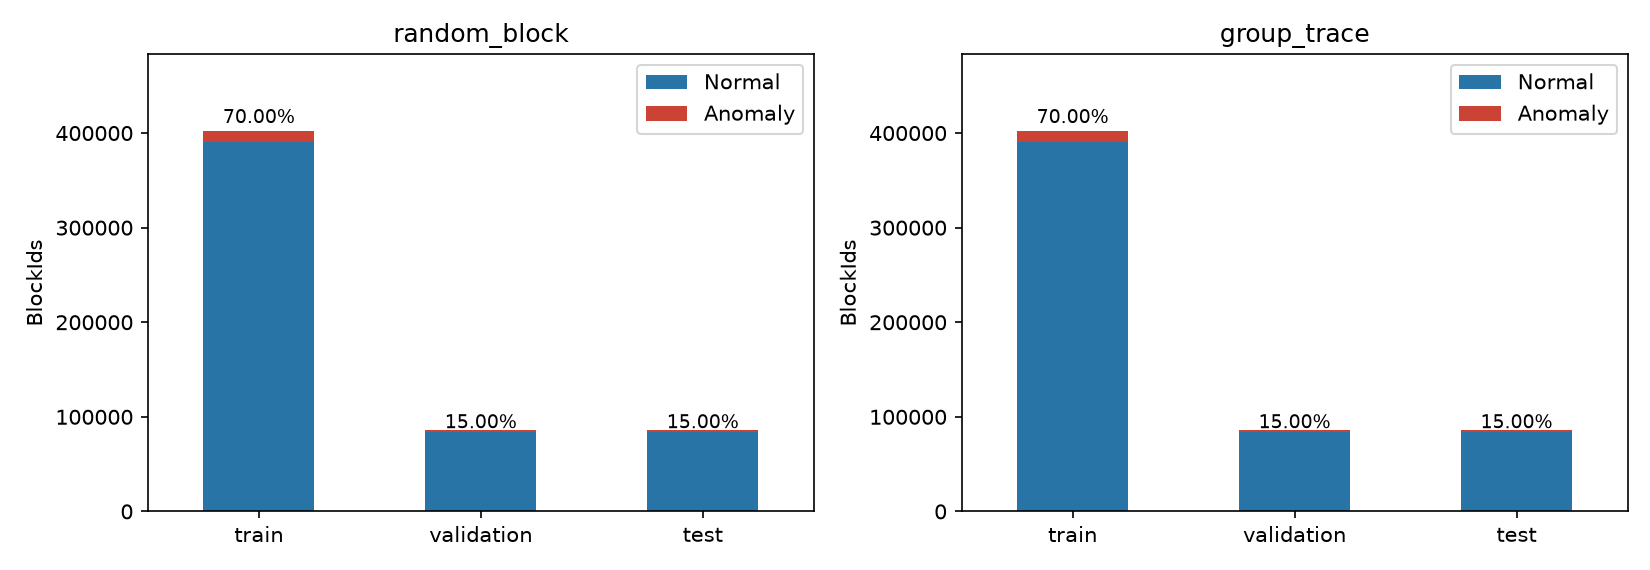

Random test seen fraction: 0.9767673723016995
Random test exact Normal KB fraction: 0.954183959748661
Anomaly queries exact-match Normal KB: 4
Báo cáo độc lập: /mnt/e/learn/Do an/code/outputs/data_understanding/prepared_verification.json


In [11]:
def verify_prepared(prepared_dir: Path, data_dir: Path, chunksize: int=20000) -> dict:
    checks = []

    def check(condition, description):
        if not condition:
            raise AssertionError(description)
        checks.append(description)
    truth = pd.read_csv(data_dir / 'anomaly_label.csv').set_index('BlockId').Label
    templates = pd.read_csv(data_dir / 'HDFS.log_templates.csv').set_index('EventId').EventTemplate
    check(truth.index.is_unique and truth.index.notna().all(), 'unique source labels')
    check(templates.index.is_unique and templates.notna().all(), 'unique valid source templates')
    check(set(truth) == {'Normal', 'Anomaly'}, 'source label vocabulary')
    payloads, parts = ({}, [])
    print('Independent verification: đọc toàn bộ block_sequences.csv...', flush=True)
    for chunk in pd.read_csv(prepared_dir / 'block_sequences.csv', chunksize=chunksize):
        if not chunk.label.eq(chunk.block_id.map(truth)).all():
            raise AssertionError('Record labels differ from source')
        for row in chunk.itertuples(index=False):
            cached = payloads.get(row.trace_signature)
            if cached is None:
                sequence = json.loads(row.event_ids)
                texts = json.loads(row.template_sequence)
                if not isinstance(sequence, list) or not sequence or (not all((isinstance(e, str) for e in sequence))):
                    raise AssertionError('Invalid event_ids JSON array')
                digest = hashlib.sha256(json.dumps(sequence, separators=(',', ':')).encode()).hexdigest()
                if digest != row.trace_signature or any((e not in templates for e in sequence)):
                    raise AssertionError('Signature or template mapping differs')
                if texts != [templates[e] for e in sequence]:
                    raise AssertionError('Template text or order differs')
                cached = (row.event_ids, row.template_sequence, len(sequence), sequence, texts)
                payloads[digest] = cached
            if cached[:3] != (row.event_ids, row.template_sequence, row.sequence_length):
                raise AssertionError('Same signature contains different sequence or length')
        parts.append(chunk[['block_id', 'trace_signature', 'label', 'conflicting_trace']])
    records = pd.concat(parts, ignore_index=True).set_index('block_id')
    check(records.index.is_unique and records.index.notna().all(), 'unique exported BlockIds')
    check(set(records.index) == set(truth.index), 'export covers every source BlockId')
    check(True, 'all JSON sequences, signatures, lengths, labels and template order validated')
    raw_cache, raw_seen = ({}, set())
    for chunk in pd.read_csv(data_dir / 'Event_traces.csv', usecols=['BlockId', 'Features'], chunksize=chunksize):
        raw_ids = []
        for value in chunk.Features:
            if value not in raw_cache:
                if not isinstance(value, str) or not value.startswith('[') or (not value.endswith(']')):
                    raise AssertionError('Invalid source feature syntax')
                events = [e.strip() for e in value[1:-1].split(',')]
                raw_cache[value] = hashlib.sha256(json.dumps(events, separators=(',', ':')).encode()).hexdigest()
            raw_ids.append(raw_cache[value])
        if chunk.BlockId.duplicated().any() or raw_seen.intersection(chunk.BlockId):
            raise AssertionError('Duplicate source trace BlockId')
        raw_seen.update(chunk.BlockId)
        if chunk.BlockId.map(records.trace_signature).tolist() != raw_ids:
            raise AssertionError('Exported sequence differs from source trace')
    check(raw_seen == set(records.index), 'every exported sequence equals its source BlockId trace')
    conflicts = records.groupby('trace_signature').label.nunique().gt(1)
    check(records.conflicting_trace.eq(records.trace_signature.map(conflicts)).all(), 'conflicting_trace recomputed from labels')
    conflict_file = pd.read_csv(prepared_dir / 'conflicting_sequences.csv').set_index('trace_signature')
    histogram = records.groupby(['trace_signature', 'label']).size().unstack(fill_value=0)
    expected_conflicts = histogram.loc[conflicts[conflicts].index].sort_index()
    pd.testing.assert_frame_equal(conflict_file.sort_index()[['Normal', 'Anomaly']], expected_conflicts[['Normal', 'Anomaly']], check_names=False)
    check(True, 'conflicting_sequences.csv matches exported labels')
    summaries, overlap_rows, compression = ([], [], [])
    for protocol in ('random_block', 'group_trace'):
        folder = prepared_dir / protocol
        split_frames = {}
        for split in ('train', 'validation', 'test'):
            part = pd.read_csv(folder / f'{split}_block_ids.csv').set_index('block_id')
            check(part.index.is_unique and part.index.notna().all(), f'{protocol}/{split}: unique BlockIds')
            check(part.split.eq(split).all(), f'{protocol}/{split}: correct split tags')
            check(set(part.index).issubset(records.index), f'{protocol}/{split}: IDs in records')
            for column in ('label', 'trace_signature'):
                check(part[column].eq(records.loc[part.index, column]).all(), f'{protocol}/{split}: {column} matches records')
            check(set(part.label) == {'Normal', 'Anomaly'}, f'{protocol}/{split}: both classes')
            split_frames[split] = part
            summaries.append({'protocol': protocol, 'split': split, 'blocks': len(part), 'Normal': int(part.label.eq('Normal').sum()), 'Anomaly': int(part.label.eq('Anomaly').sum()), 'block_fraction': len(part) / len(records), 'anomaly_prevalence': float(part.label.eq('Anomaly').mean())})
        combined = pd.concat(split_frames.values())
        check(combined.index.is_unique, f'{protocol}: no cross-split BlockId overlap')
        check(set(combined.index) == set(records.index), f'{protocol}: union equals all records')
        if protocol == 'group_trace':
            check(combined.groupby('trace_signature').split.nunique().eq(1).all(), 'group_trace: no cross-split sequence overlap')
        normal_train = split_frames['train'].loc[split_frames['train'].label.eq('Normal')]
        expected_counts = normal_train.groupby('trace_signature').size().sort_index()
        kb = pd.read_csv(folder / 'normal_knowledge_base.csv').set_index('trace_id')
        check(kb.index.is_unique and kb.index.notna().all(), f'{protocol}: unique canonical KB traces')
        check(set(kb.index) == set(expected_counts.index), f'{protocol}: KB exactly covers Normal train patterns')
        check(kb.occurrence_count.sort_index().eq(expected_counts).all(), f'{protocol}: KB counts equal Normal train counts')
        check(set(kb.representative_block_id).issubset(normal_train.index), f'{protocol}: all representatives in Normal train')
        for trace_id, row in kb.iterrows():
            sequence, texts = payloads[trace_id][3:]
            if json.loads(row.event_ids) != sequence or row.template_text != '\n'.join((f'{e}: {t}' for e, t in zip(sequence, texts))):
                raise AssertionError('KB payload differs from canonical source sequence')
            if records.loc[row.representative_block_id, 'trace_signature'] != trace_id:
                raise AssertionError('KB representative belongs to a different pattern')
        check(True, f'{protocol}: KB payload and representative sequence checked')
        compression.append({'protocol': protocol, 'normal_train_blocks': len(normal_train), 'canonical_normal_traces': len(kb), 'retained_record_fraction': len(kb) / len(normal_train)})
        train_signatures = set(split_frames['train'].trace_signature)
        for split in ('validation', 'test'):
            for label in ('Normal', 'Anomaly'):
                queries = split_frames[split].loc[split_frames[split].label.eq(label)]
                seen = queries.trace_signature.isin(train_signatures)
                exact = queries.trace_signature.isin(kb.index)
                overlap_rows.append({'protocol': protocol, 'split': split, 'query_label': label, 'query_blocks': len(queries), 'seen_blocks': int(seen.sum()), 'unseen_blocks': int((~seen).sum()), 'seen_trace_rate': float(seen.mean()), 'unseen_trace_rate': float((~seen).mean()), 'exact_match_in_normal_kb': int(exact.sum()), 'exact_match_rate': float(exact.mean())})
        annotations = pd.read_csv(folder / 'evaluation_annotations.csv').set_index('block_id')
        evaluation = pd.concat([split_frames['validation'], split_frames['test']])
        check(annotations.index.is_unique and set(annotations.index) == set(evaluation.index), f'{protocol}: annotation coverage')
        for column in ('trace_signature', 'label', 'split'):
            check(annotations[column].eq(evaluation.loc[annotations.index, column]).all(), f'{protocol}: annotation {column}')
        for column, expected in {'seen_in_train': annotations.trace_signature.isin(train_signatures), 'exact_match_in_normal_kb': annotations.trace_signature.isin(kb.index), 'conflicting_trace': annotations.trace_signature.map(conflicts)}.items():
            check(annotations[column].eq(expected).all(), f'{protocol}: annotation {column}')
    return {'status': 'passed', 'verification_schema_version': 1, 'prepared_dir': str(prepared_dir.resolve()), 'blocks_checked': len(records), 'check_count': len(checks), 'checks': checks, 'split_composition': summaries, 'overlap_by_query_label': overlap_rows, 'kb_compression': compression, 'independence': 'Recomputed from all records, source CSVs, manifests and KB; no producer function or JSON report used'}
verification = verify_prepared(prepared_dir, data_dir, chunksize)
(output / 'prepared_verification.json').write_text(json.dumps(verification, ensure_ascii=False, indent=2) + '\n')
composition = pd.DataFrame(verification['split_composition'])
overlap_by_label = pd.DataFrame(verification['overlap_by_query_label'])
compression = pd.DataFrame(verification['kb_compression'])
overlap_by_label.to_csv(output / 'split_overlap_by_query_label.csv', index=False)
print(f"PASS: {verification['check_count']} checks, {verification['blocks_checked']:,} BlockIds")
display(composition)
display(overlap_by_label)
display(compression)
from scripts.eda_visuals import make_split_plot
split_figure = make_split_plot(composition, output)
display(Image(filename=str(split_figure)))
# Các kết luận dưới đây được tính từ kết quả verifier, không dùng số hard-code.
random_test = overlap_by_label.query("protocol == 'random_block' and split == 'test'")
print('Random test seen fraction:', random_test.seen_blocks.sum() / random_test.query_blocks.sum())
print('Random test exact Normal KB fraction:', random_test.exact_match_in_normal_kb.sum() / random_test.query_blocks.sum())
print('Anomaly queries exact-match Normal KB:', int(random_test.loc[random_test.query_label.eq('Anomaly'), 'exact_match_in_normal_kb'].sum()))
print('Báo cáo độc lập:', output / 'prepared_verification.json')
